In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV

In [2]:
df = pd.read_csv('E:\ML with VS\material addition\Corrected\material_addition.csv')

<>:1: SyntaxWarning: invalid escape sequence '\M'
<>:1: SyntaxWarning: invalid escape sequence '\M'
C:\Users\SAIDUL\AppData\Local\Temp\ipykernel_6908\2072630213.py:1: SyntaxWarning: invalid escape sequence '\M'
  df = pd.read_csv('E:\ML with VS\material addition\Corrected\material_addition.csv')


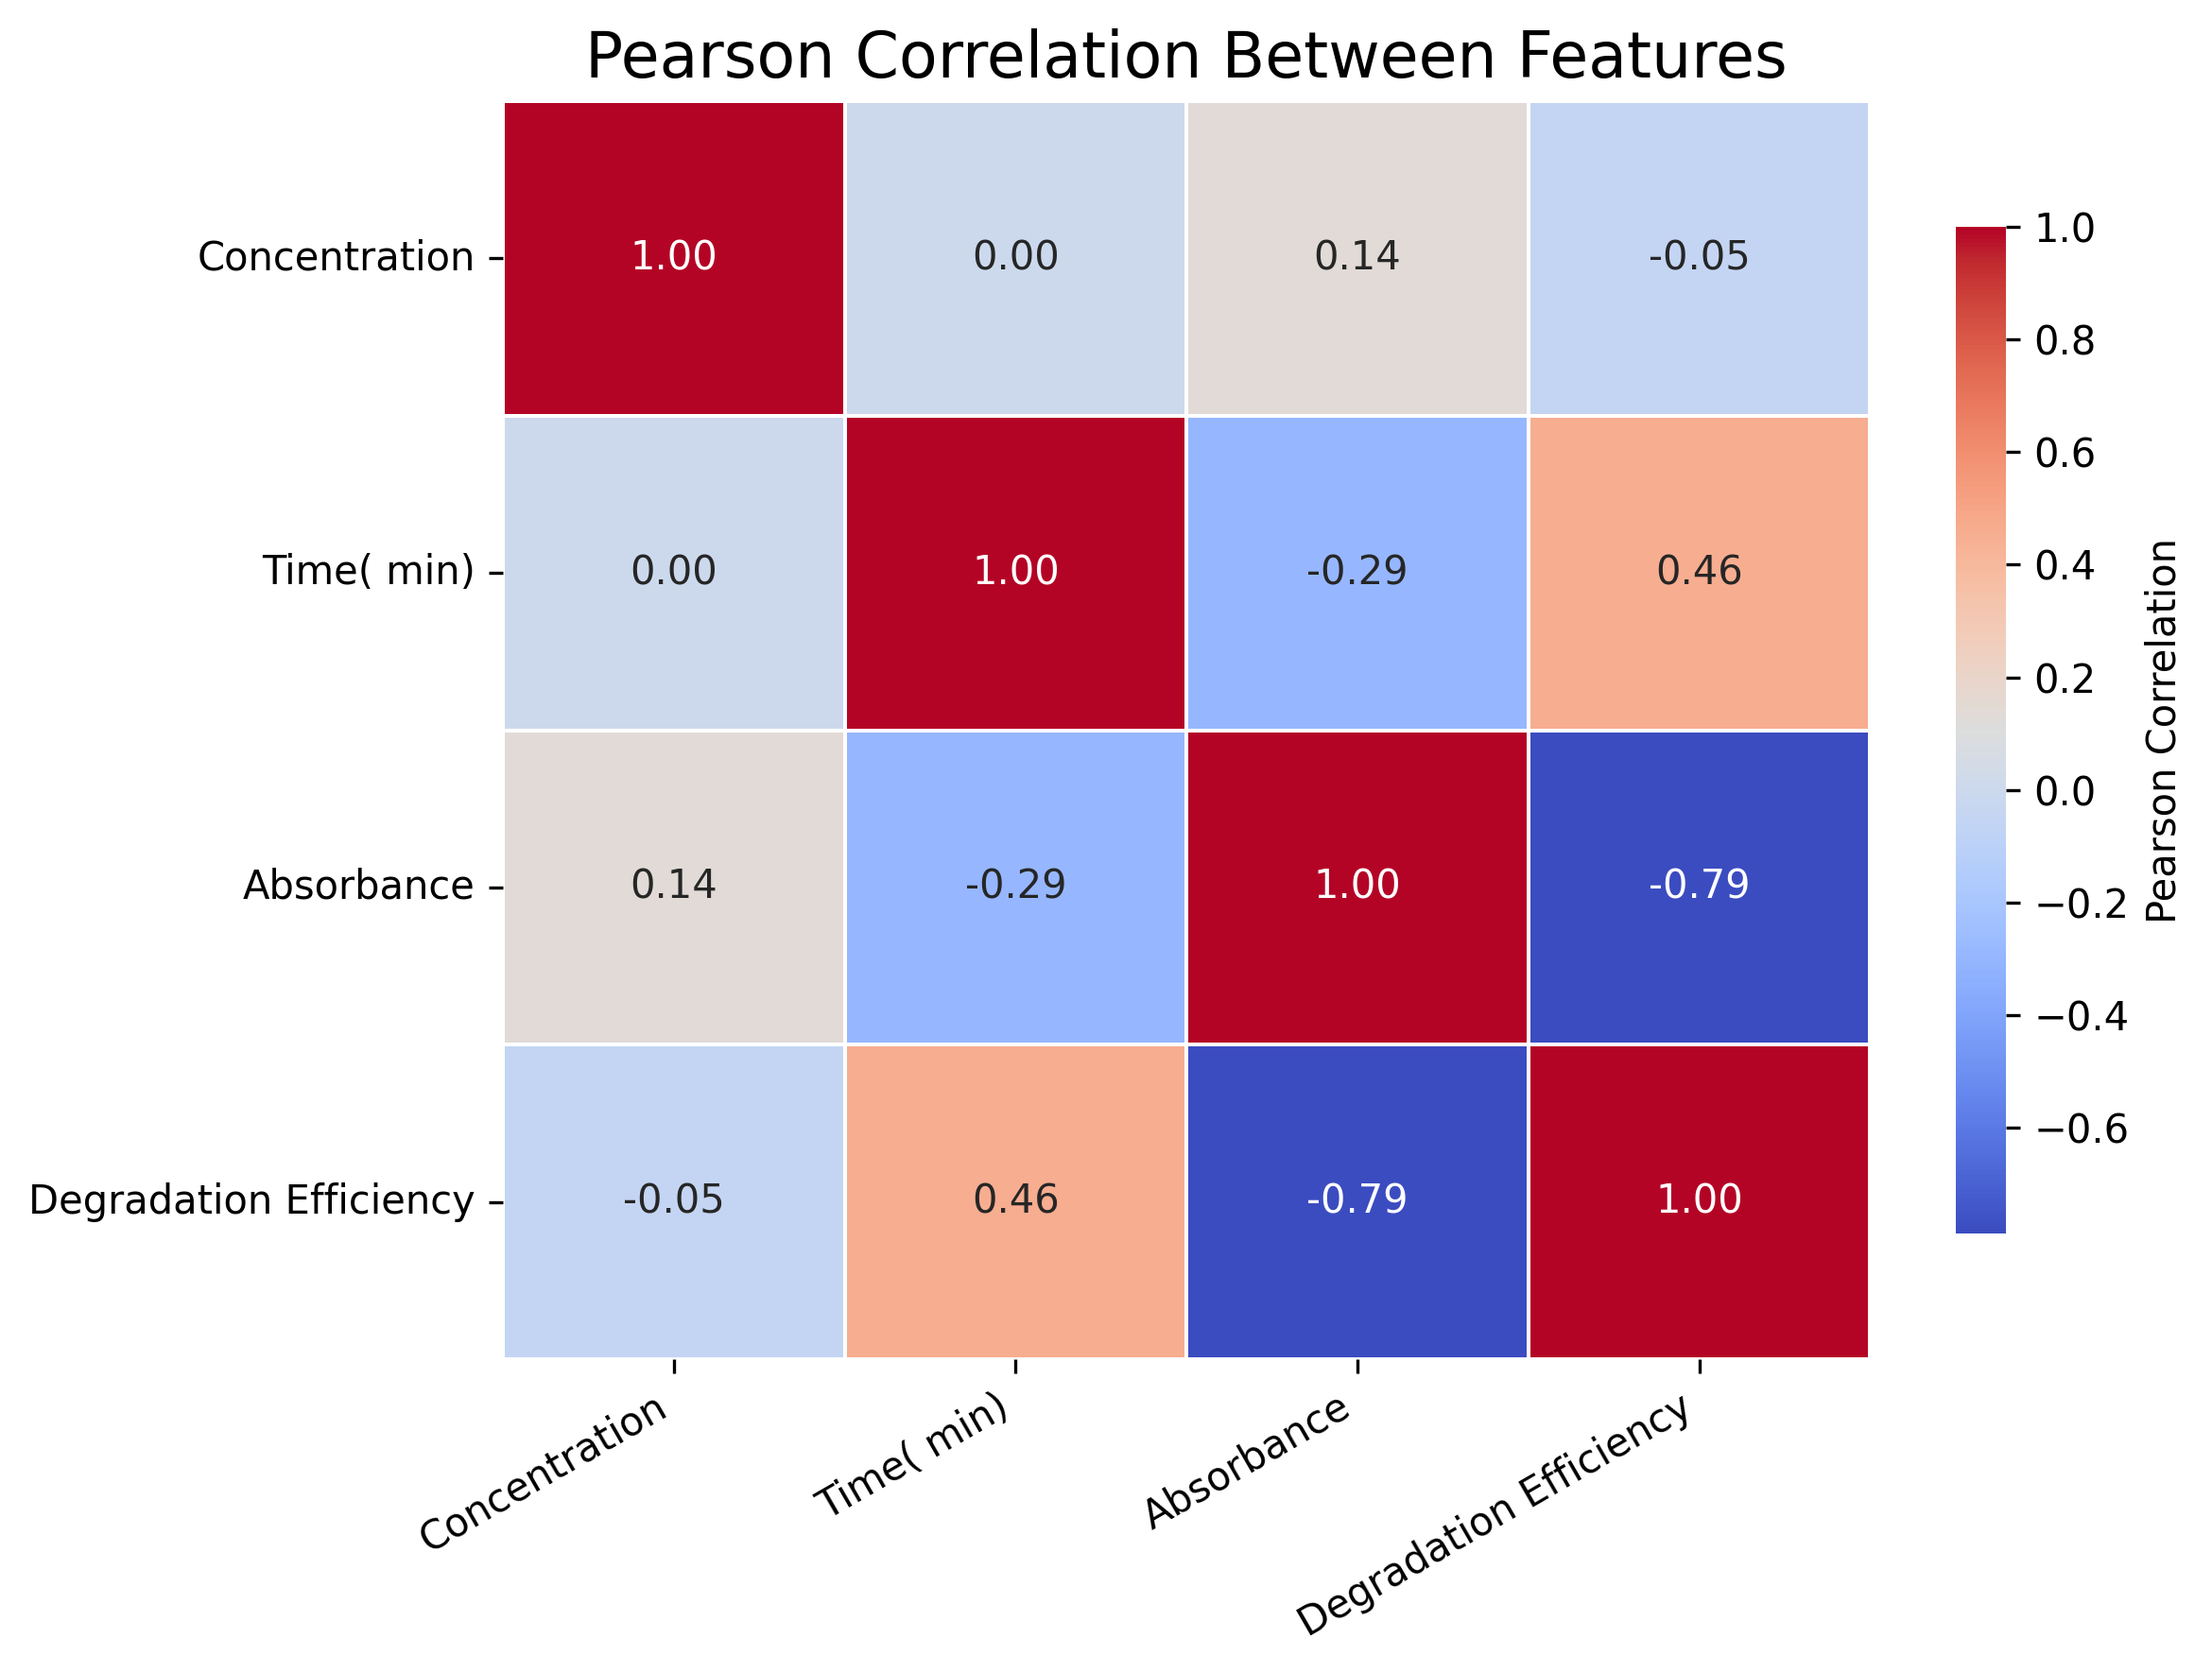

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Drop non-feature and target columns
features_df = df.drop(columns=["Nanomaterials Name"])

# Calculate Pearson correlation
corr_matrix = features_df.corr(method="pearson")

# Customization options
fig_width = 8      # Width in inches
fig_height = 6    # Height in inches
dpi_value = 300      # DPI (resolution)
cmap_style = "coolwarm"  # Color map
annot = True         # Show correlation numbers
fmt = ".2f"          # Number format
line_width = 0.5     # Lines between squares
cbar_shrink = 0.8    # Color bar size
label_rotation_x = 30
label_rotation_y = 0

# Create figure with custom size and DPI
fig, ax = plt.subplots(figsize=(fig_width, fig_height), dpi=dpi_value)

# Plot full heatmap
sns.heatmap(
    corr_matrix,
    annot=annot,
    cmap=cmap_style,
    fmt=fmt,
    linewidths=line_width,
    cbar_kws={"shrink": cbar_shrink, "label": "Pearson Correlation"},
    ax=ax
)

# Customize labels
plt.xticks(rotation=label_rotation_x, ha="right")
plt.yticks(rotation=label_rotation_y)
plt.title("Pearson Correlation Between Features", fontsize=16)
plt.tight_layout()
plt.show()




In [4]:
# Features: all numeric columns except Nanomaterial Name and target
X = df.drop(columns=["Nanomaterials Name", "Degradation Efficiency"])

# Target variable
y = df["Degradation Efficiency"]



In [5]:
# Keep sample IDs
sample_ids = df["Nanomaterials Name"].values  # first column with sample names

# Split features, target, and sample IDs together
X_train, X_test, y_train, y_test, ids_train, ids_test = train_test_split(
    X, y, sample_ids, test_size=0.2, random_state=42
)
print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")


Training samples: 316
Test samples: 80


In [ ]:
from sklearn.preprocessing import StandardScaler



scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, cross_val_score, cross_val_predict
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Model initialization
xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

# Parameter grid for tuning
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.7, 0.9],
    'colsample_bytree': [0.7, 0.9],
    'gamma': [0, 0.1],
    'reg_alpha': [0, 0.1],
    'reg_lambda': [1, 2]
}

# Grid search with 5-fold cross-validation
grid_search = GridSearchCV(xgb, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

# Best model selection
best_xg_model = grid_search.best_estimator_

# Predictions
y_train_pred_xg = best_xg_model.predict(X_train_scaled)
y_test_pred_xg = best_xg_model.predict(X_test_scaled)

# Cross-validated predictions on training set (for Q²)
y_cv_pred = cross_val_predict(best_xg_model, X_train_scaled, y_train, cv=5)

# Evaluation metrics
# --- Train Set ---
r2_train = r2_score(y_train, y_train_pred_xg)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred_xg))
mae_train = mean_absolute_error(y_train, y_train_pred_xg)

# --- Test Set ---
r2_test = r2_score(y_test, y_test_pred_xg)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred_xg))
mae_test = mean_absolute_error(y_test, y_test_pred_xg)

# --- Cross-Validation ---
neg_mse_cv_scores = cross_val_score(best_xg_model, X_train_scaled, y_train, scoring='neg_mean_squared_error', cv=5)
rmse_cv = np.mean(np.sqrt(-neg_mse_cv_scores))  # RMSECV
q2 = r2_score(y_train, y_cv_pred)  # Q²

# Print results
print(f"Train R²: {r2_train:.4f}, RMSE: {rmse_train:.4f}, MAE: {mae_train:.4f}")
print(f"Test R²: {r2_test:.4f}, RMSE: {rmse_test:.4f}, MAE: {mae_test:.4f}")
print(f"Cross-validated RMSE: {rmse_cv:.4f}, Q²: {q2:.4f}")


Train R²: 0.9972, RMSE: 0.0138, MAE: 0.0102
Test R²: 0.9797, RMSE: 0.0325, MAE: 0.0240
Cross-validated RMSE: 0.0376, Q²: 0.9787


In [12]:
print("Model XGBoost Regressor")
print("===== Train Set Metrics =====")
print(f"R² (Train): {r2_train:.4f}")
print(f"RMSE (Train): {rmse_train:.4f}")
print(f"MAE (Train): {mae_train:.4f}")

print("\n===== Test Set Metrics =====")
print(f"R² (Test): {r2_test:.4f}")
print(f"RMSE (Test): {rmse_test:.4f}")
print(f"MAE (Test): {mae_test:.4f}")

print("\n===== Cross-Validation Metrics =====")
print(f"Q² (Cross-validated R²): {q2:.4f}")
print(f"RMSECV: {rmse_cv:.4f}")

print("\n===== Best Hyperparameters =====")
print(grid_search.best_params_)


Model XGBoost Regressor
===== Train Set Metrics =====
R² (Train): 0.9972
RMSE (Train): 0.0138
MAE (Train): 0.0102

===== Test Set Metrics =====
R² (Test): 0.9797
RMSE (Test): 0.0325
MAE (Test): 0.0240

===== Cross-Validation Metrics =====
Q² (Cross-validated R²): 0.9787
RMSECV: 0.0376

===== Best Hyperparameters =====
{'colsample_bytree': 0.7, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'reg_alpha': 0, 'reg_lambda': 1, 'subsample': 0.9}


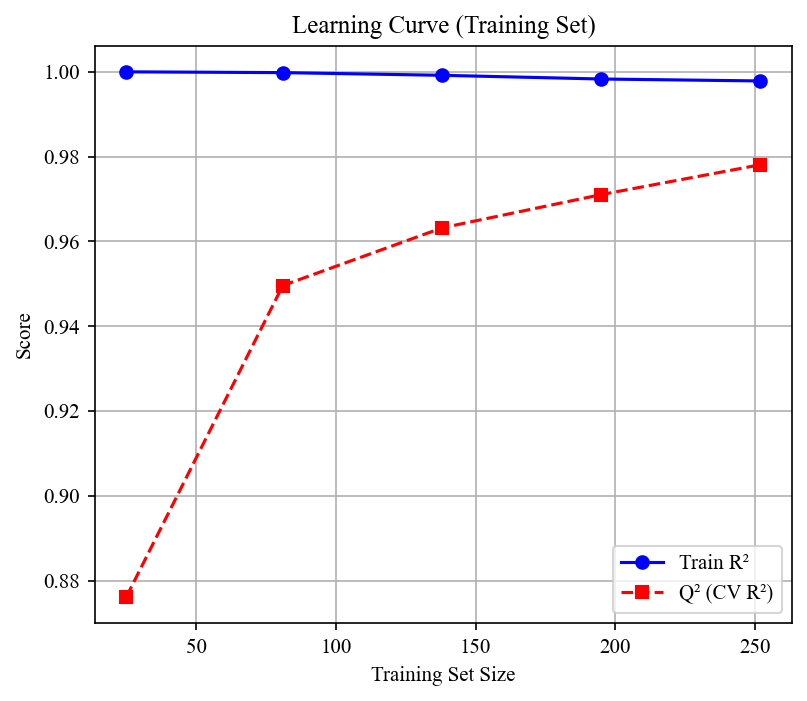

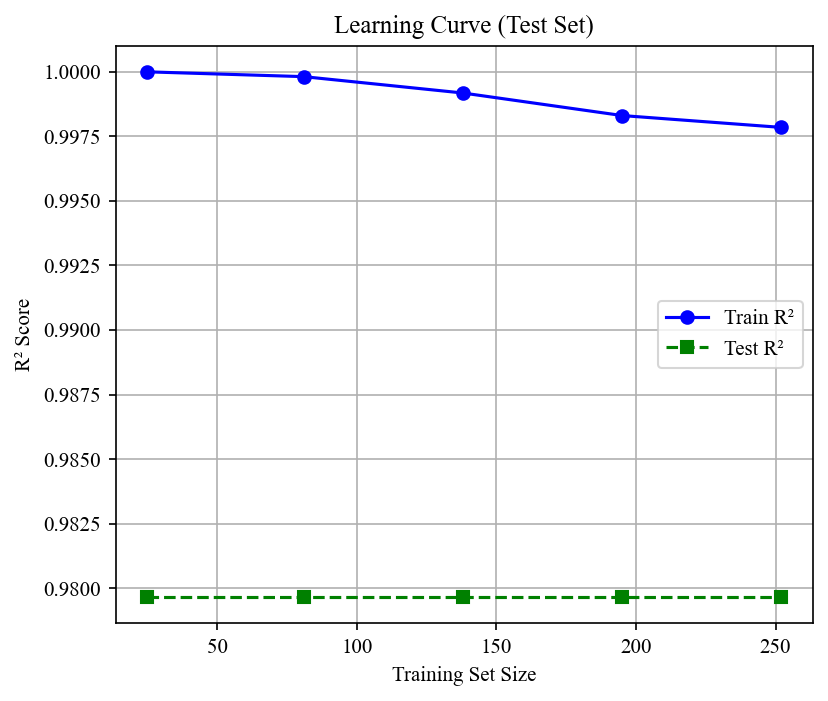

In [13]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Times New Roman'
dpi = 150

# --- 1. Learning Curve for Training Set (R² and Q²) ---
train_sizes, train_scores, cv_scores = learning_curve(
    best_xg_model, X_train_scaled, y_train, cv=5,
    scoring='r2', n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = np.mean(train_scores, axis=1)
cv_mean = np.mean(cv_scores, axis=1)

plt.figure(figsize=(6,5), dpi=dpi)
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Train R²')
plt.plot(train_sizes, cv_mean, 's--', color='red', label='Q² (CV R²)')
plt.xlabel('Training Set Size')
plt.ylabel('Score')
plt.title('Learning Curve (Training Set)')
plt.legend()
plt.grid(True)
plt.show()


# --- 2. Learning Curve for Test Set (Train R² vs Test R²) ---
train_sizes, train_scores_test, test_scores = learning_curve(
    best_xg_model, X_train_scaled, y_train, cv=5,
    scoring='r2', n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean_test = np.mean(train_scores_test, axis=1)
test_mean = []
for size in train_sizes:
    # Train on subset
    idx = int(size * X_train_scaled.shape[0])
    best_xg_model.fit(X_train_scaled[:idx], y_train[:idx])
    y_test_pred = best_xg_model.predict(X_test_scaled)
    test_mean.append(r2_score(y_test, y_test_pred))

plt.figure(figsize=(6,5), dpi=dpi)
plt.plot(train_sizes, train_mean_test, 'o-', color='blue', label='Train R²')
plt.plot(train_sizes, test_mean, 's--', color='green', label='Test R²')
plt.xlabel('Training Set Size')
plt.ylabel('R² Score')
plt.title('Learning Curve (Test Set)')
plt.legend()
plt.grid(True)
plt.show()


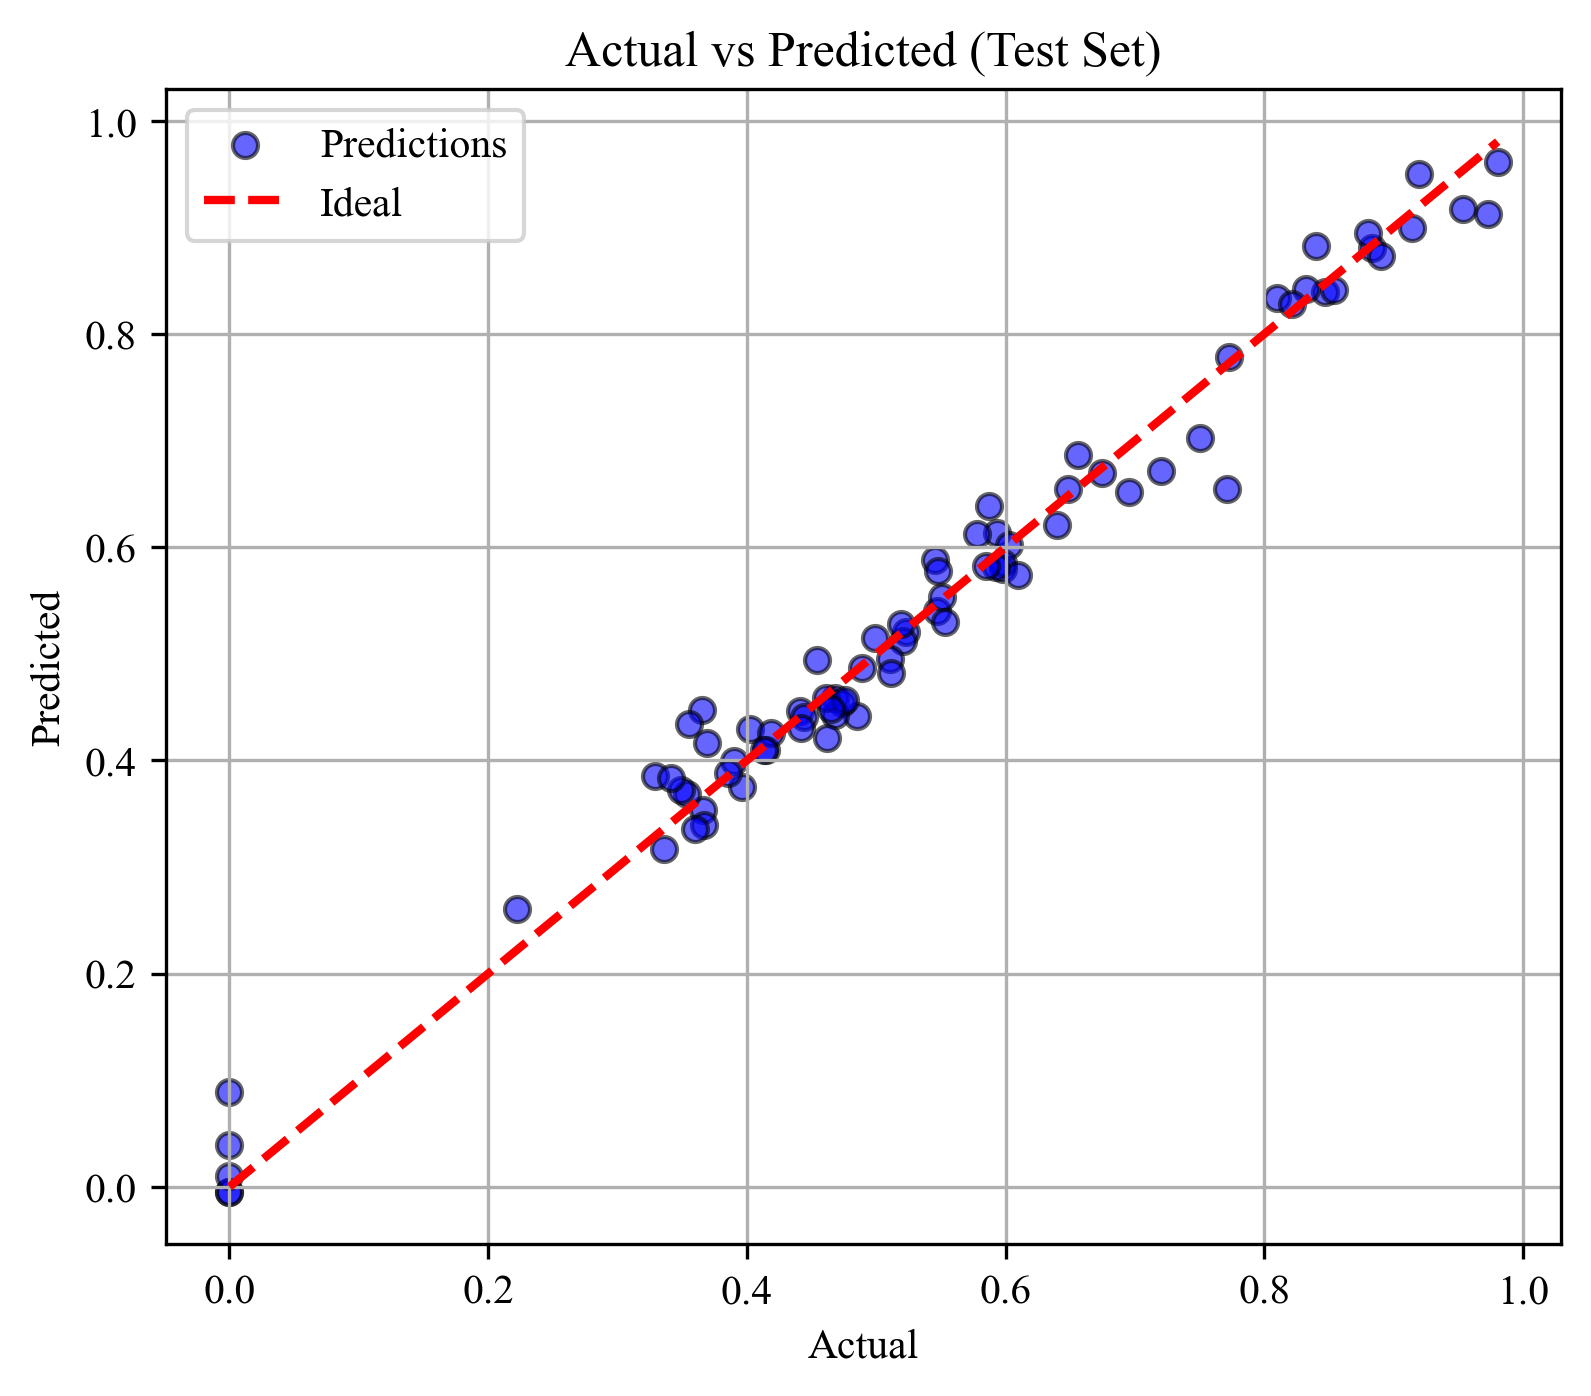

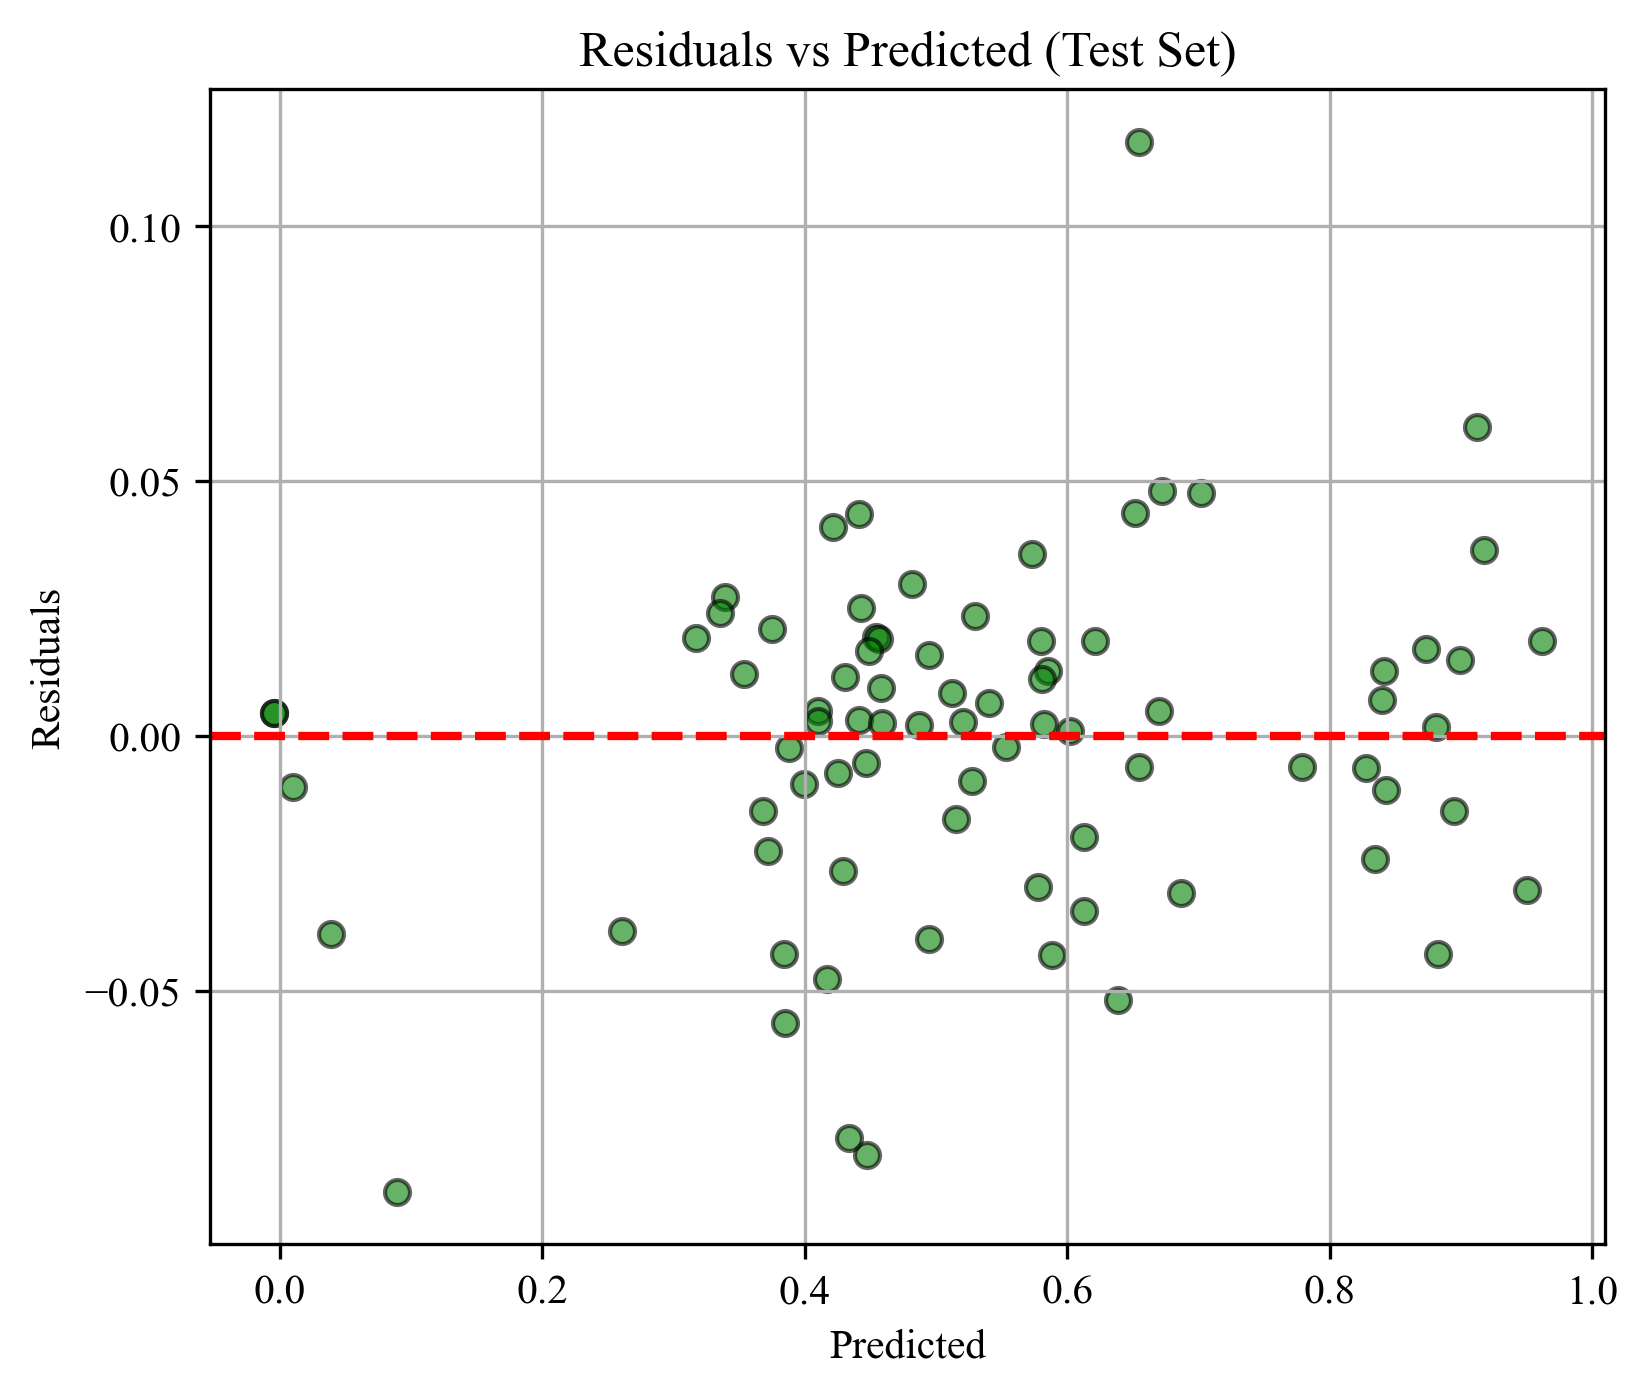

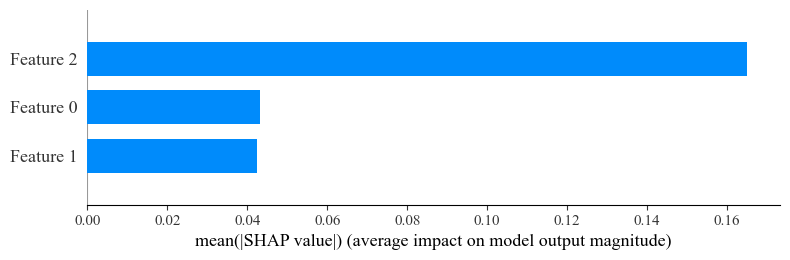

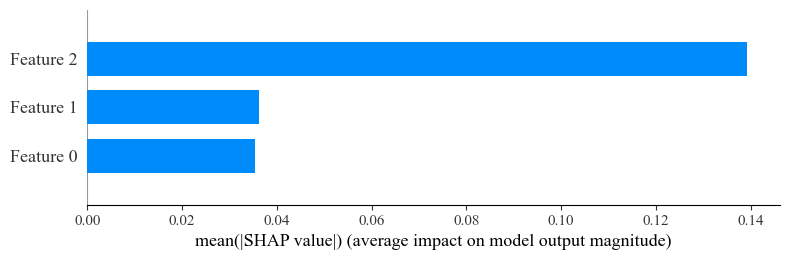

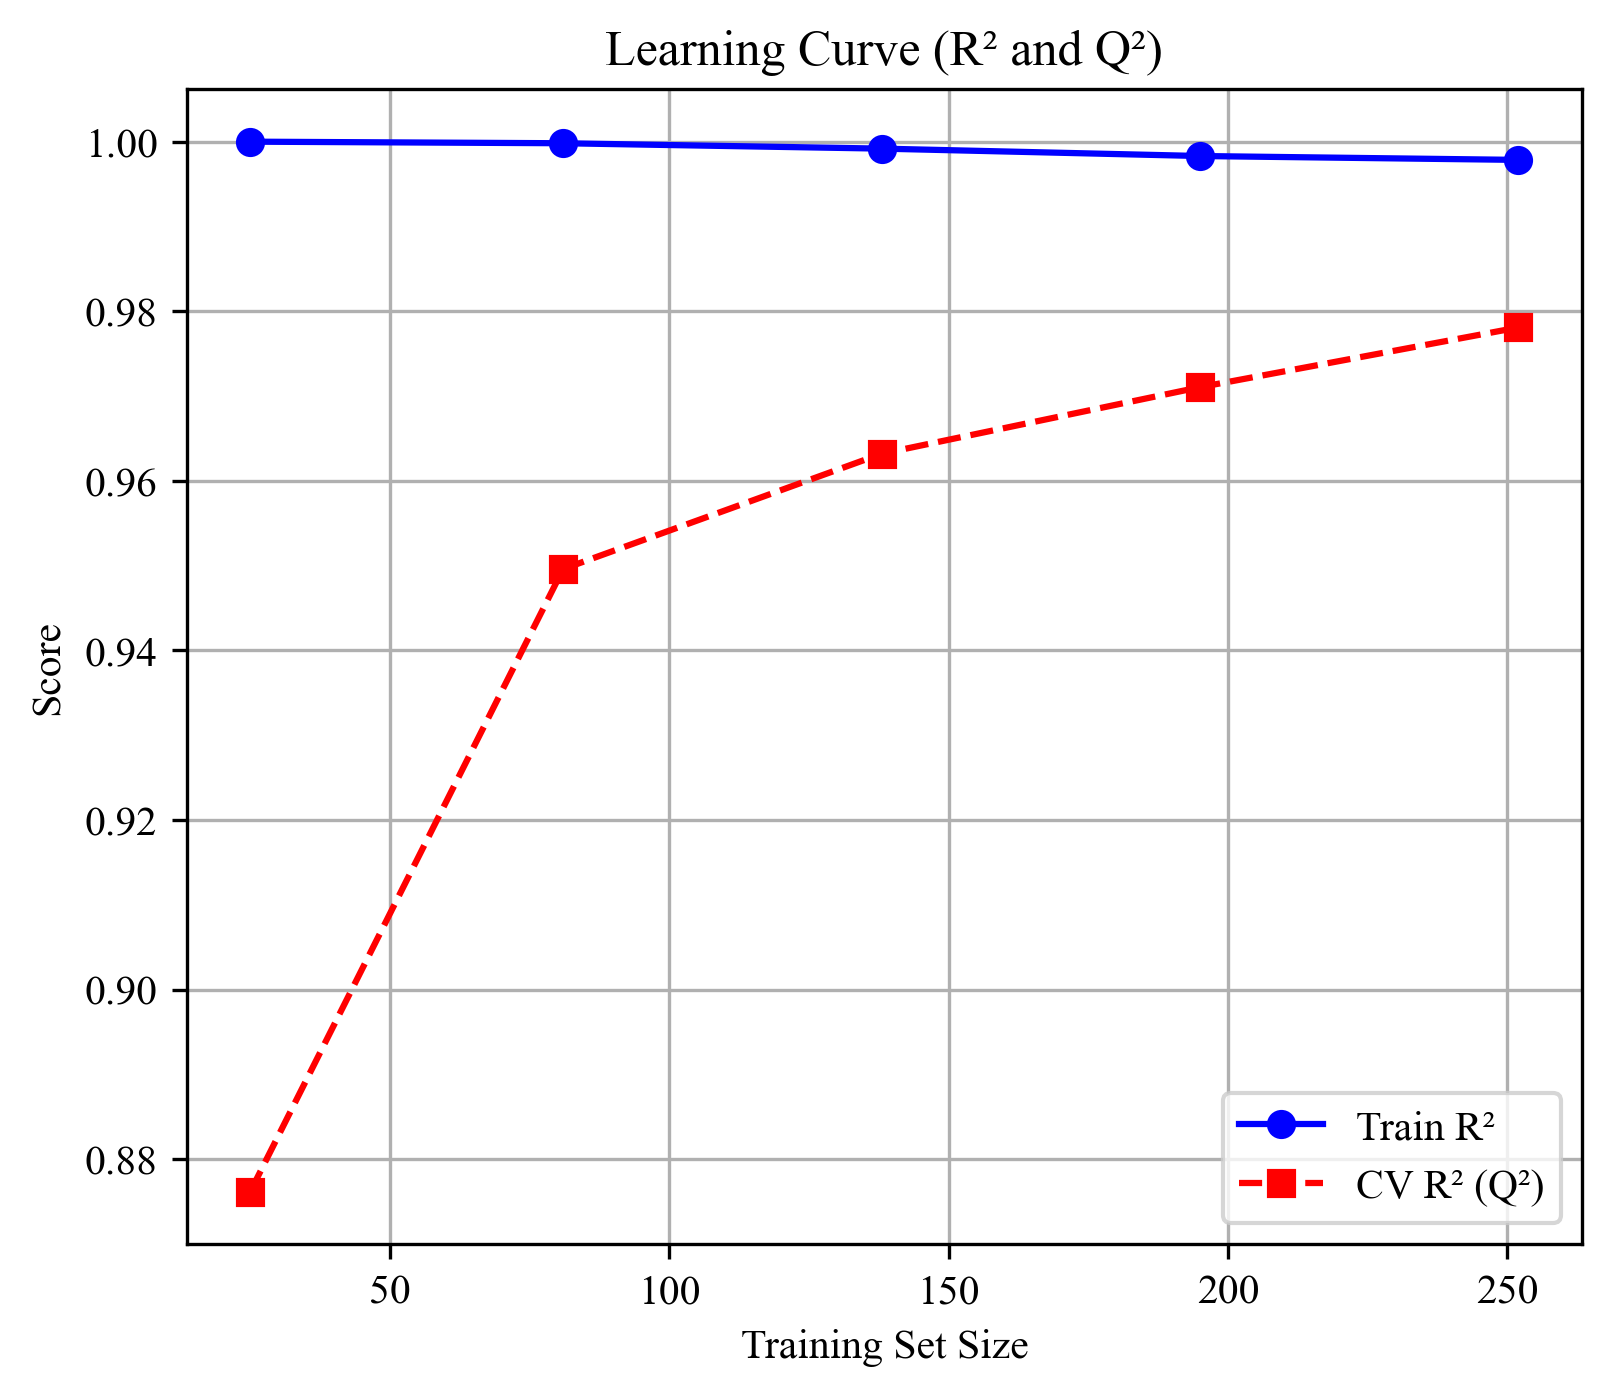

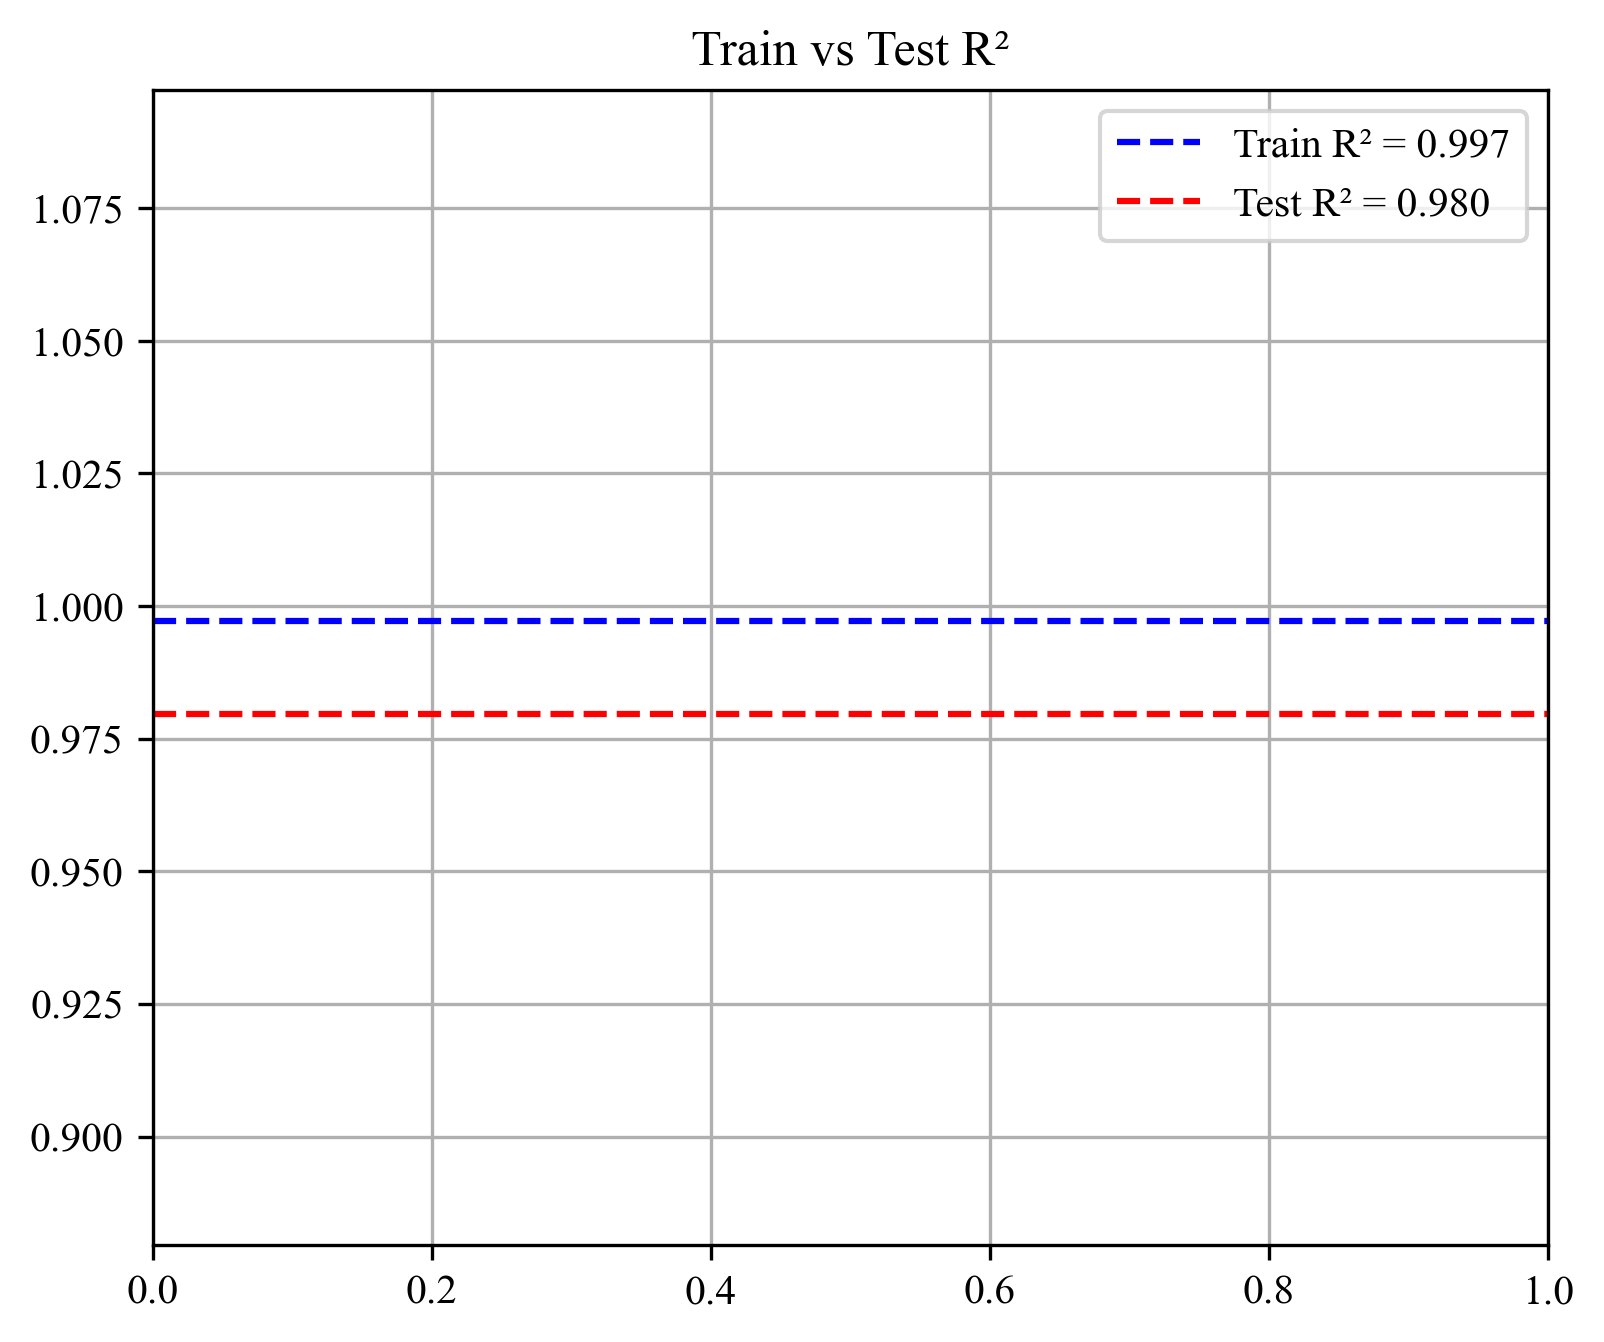

In [15]:
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import learning_curve
import numpy as np

plt.rcParams['font.family'] = 'Times New Roman'
dpi = 300

# --- 1. Actual vs Predicted (Test Set) ---
plt.figure(figsize=(6,5), dpi=dpi)
plt.scatter(y_test, y_test_pred_xg, c='blue', alpha=0.6, edgecolors='k', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted (Test Set)')
plt.legend()
plt.grid(True)
plt.show()

# --- 2. Residual Plot (Test Set) ---
residuals = y_test - y_test_pred_xg
plt.figure(figsize=(6,5), dpi=dpi)
plt.scatter(y_test_pred_xg, residuals, c='green', alpha=0.6, edgecolors='k')
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted (Test Set)')
plt.grid(True)
plt.show()

# --- 3. SHAP Values ---
explainer = shap.Explainer(best_xg_model, X_train_scaled)
shap_values_train = explainer(X_train_scaled)
shap_values_test = explainer(X_test_scaled)

# SHAP summary plot for train
shap.summary_plot(shap_values_train, X_train_scaled, plot_type="bar", show=True)

# SHAP summary plot for test
shap.summary_plot(shap_values_test, X_test_scaled, plot_type="bar", show=True)

# --- 4. Learning Curve (R² and Q²) ---
train_sizes, train_scores, valid_scores = learning_curve(
    best_xg_model, X_train_scaled, y_train, cv=5,
    scoring='r2', n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = np.mean(train_scores, axis=1)
valid_mean = np.mean(valid_scores, axis=1)

plt.figure(figsize=(6,5), dpi=dpi)
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Train R²')
plt.plot(train_sizes, valid_mean, 's--', color='red', label='CV R² (Q²)')
plt.xlabel('Training Set Size')
plt.ylabel('Score')
plt.title('Learning Curve (R² and Q²)')
plt.legend()
plt.grid(True)
plt.show()

# --- 5. Train vs Test R² Curve ---
plt.figure(figsize=(6,5), dpi=dpi)
plt.plot([0,1],[r2_train,r2_train],'b--', label=f'Train R² = {r2_train:.3f}')
plt.plot([0,1],[r2_test,r2_test],'r--', label=f'Test R² = {r2_test:.3f}')
plt.xlim(0,1)
plt.ylim(min(r2_test,r2_train)-0.1, max(r2_test,r2_train)+0.1)
plt.title('Train vs Test R²')
plt.legend()
plt.grid(True)
plt.show()


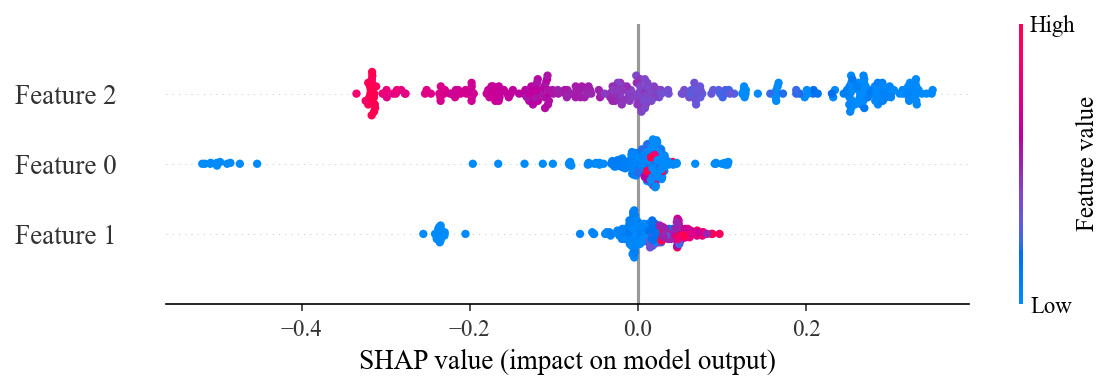

In [16]:
import shap
import matplotlib.pyplot as plt

# Initialize SHAP explainer
explainer = shap.Explainer(best_xg_model, X_train_scaled)

# Calculate SHAP values
shap_values = explainer(X_train_scaled)

# Customization options
top_n_features = 20              # Show only top 20 features
fig_size = (14, 10)              # Figure size
dpi_setting = 150                # DPI of the figure
font_name = "Times New Roman"    # Font

# Apply font globally
plt.rcParams["font.family"] = font_name

# Plot SHAP summary dot plot
plt.figure(figsize=fig_size, dpi=dpi_setting)
shap.summary_plot(
    shap_values, 
    X_train_scaled, 
    plot_type="dot", 
    max_display=top_n_features,
    show=True
)


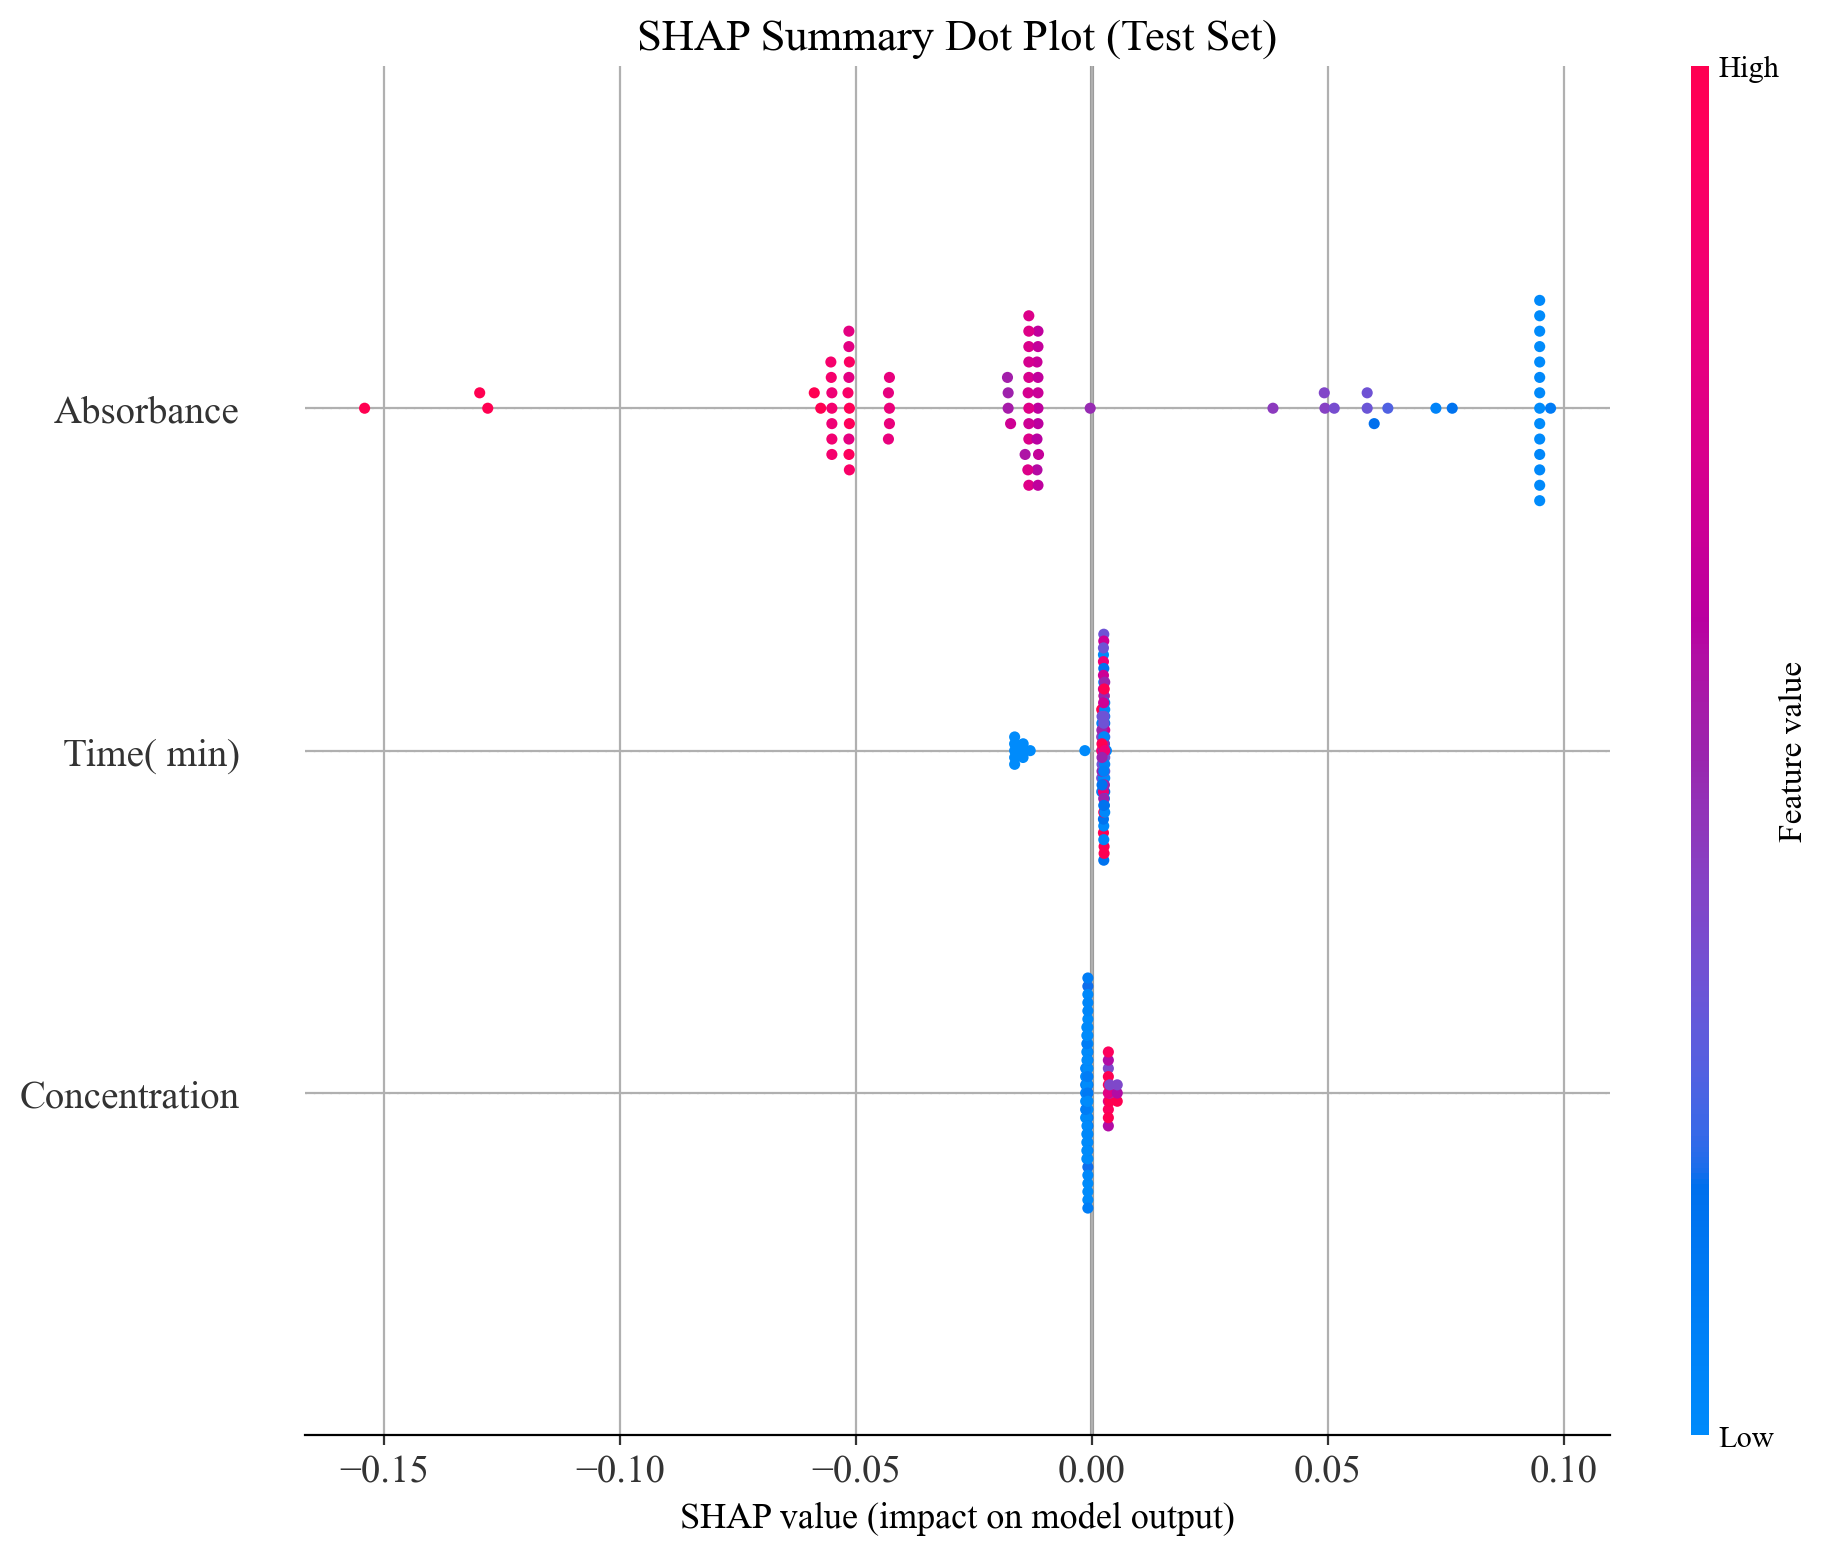

In [18]:
import shap
import matplotlib.pyplot as plt

def plot_shap_summary_dot(shap_values, X, title, save_path,
                          dpi=300, figsize=(8, 6), font_size=12, top_features=20):
    # Set font and figure quality
    plt.rcParams["font.family"] = "Times New Roman"
    plt.rcParams["font.size"] = font_size
    plt.rcParams["axes.grid"] = True   # Keep grid lines
    plt.rcParams["figure.dpi"] = dpi

    # Plot SHAP summary (dot plot)
    shap.summary_plot(
        shap_values, 
        X, 
        show=False, 
        max_display=top_features,  # Show top N features
        plot_size=figsize
    )

    # Apply styling after SHAP draws the plot
    fig = plt.gcf()
    ax = plt.gca()
    ax.set_title(title, fontsize=font_size + 2)
    ax.tick_params(axis='both', labelsize=font_size)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
    plt.show()


# SHAP explainer
explainer = shap.Explainer(best_xg_model, X_test)
shap_values = explainer(X_test)

# Plot and save
plot_shap_summary_dot(
    shap_values,
    X_test,
    "SHAP Summary Dot Plot (Test Set)",
    "shap_summary_dot.png",
    dpi=200,
    figsize=(10, 8),
    font_size=14,
    top_features=20
)

